# Melville Bugt dyke swarm ca. 1633 Ma paleomagnetic pole

## Geologic context

The Melville Bugt dyke swarm trends north-northwest for ~1000 km along the west
coast of Greenland (Halls, Hamilton & Denyszyn, 2011). The dykes are alkaline
trachybasalts, 100-200 m wide, with a remarkably constant geochemistry along the
swarm. Halls et al. proposed the swarm as a possible Laurentia-Greenland
connection to the 1.5-1.6 Ga Fennoscandian rapakivi-granite province. U-Pb
baddeleyite dating gives ca. 1633 Ma (1635 ± 2.7, 1632 ± 1.1, 1629.4 ± 0.8 Ma).

## Pole

This notebook recreates the Melville Bugt pole at the site level from the 9 dykes
that carry a primary magnetite remanence (Halls et al., 2011). The swarm is of
mixed polarity (a positive reversal test), and chilled-margin sampling with
geochemical fingerprinting was used to avoid double-counting duplicate dykes.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from `../data/1633_Melville_Bugt/`. The pole uses the 9
dykes with a stable primary direction; secondary-component and present-field
(PEF) sites, and the OF chilled margin (the margin of the OF dyke), are excluded.
Directions are in-situ (dykes).

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/1633_Melville_Bugt/sites.txt')
primary = sites_geo[(sites_geo['dir_comp_name'] == 'primary') &
                    (sites_geo['vgp_lat'].notna()) &
                    (sites_geo['site'] != 'OF Margin')].reset_index(drop=True)
study_lat = round(primary['lat'].mean(), 1)
study_lon = round(primary['lon'].mean(), 1)
print(f'{len(primary)} dykes for the pole; study locality ~{study_lat} N, {study_lon} E')
primary[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k',
         'dir_n_samples', 'vgp_lat', 'vgp_lon']]

9 dykes for the pole; study locality ~74.4 N, 301.6 E


,site,lat,lon,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,vgp_lat,vgp_lon
0,MB1,69.8669,309.3799,39.3,-44.5,7.0,64.0,8.0,10.1,274.1
1,MB2,69.8984,309.5521,26.9,-14.9,11.7,62.0,4.0,-10.4,282.5
2,MB4,74.4829,303.6652,30.3,-29.3,9.1,72.0,5.0,2.2,274.6
3,MB5,74.5579,303.7798,209.1,46.6,4.9,186.0,6.0,14.2,277.5
4,MB7,74.2886,303.7271,51.9,-8.5,9.6,64.0,5.0,-5.4,251.7
5,MB9,73.9129,304.0582,201.2,50.1,5.6,142.0,6.0,15.7,285.2
6,QT,77.4781,293.5744,195.9,28.8,8.8,41.0,9.0,3.3,278.2
7,JP,77.5933,293.1183,209.1,44.2,3.0,40.0,7.0,15.0,266.2
8,OF,77.1058,293.7330,13.1,-6.7,10.5,25.0,7.0,-9.2,280.5


## Mean pole and the reversal test

The swarm carries both normal and reversed dykes ~180° apart (a positive reversal
test); polarity is unified before the Fisher mean.

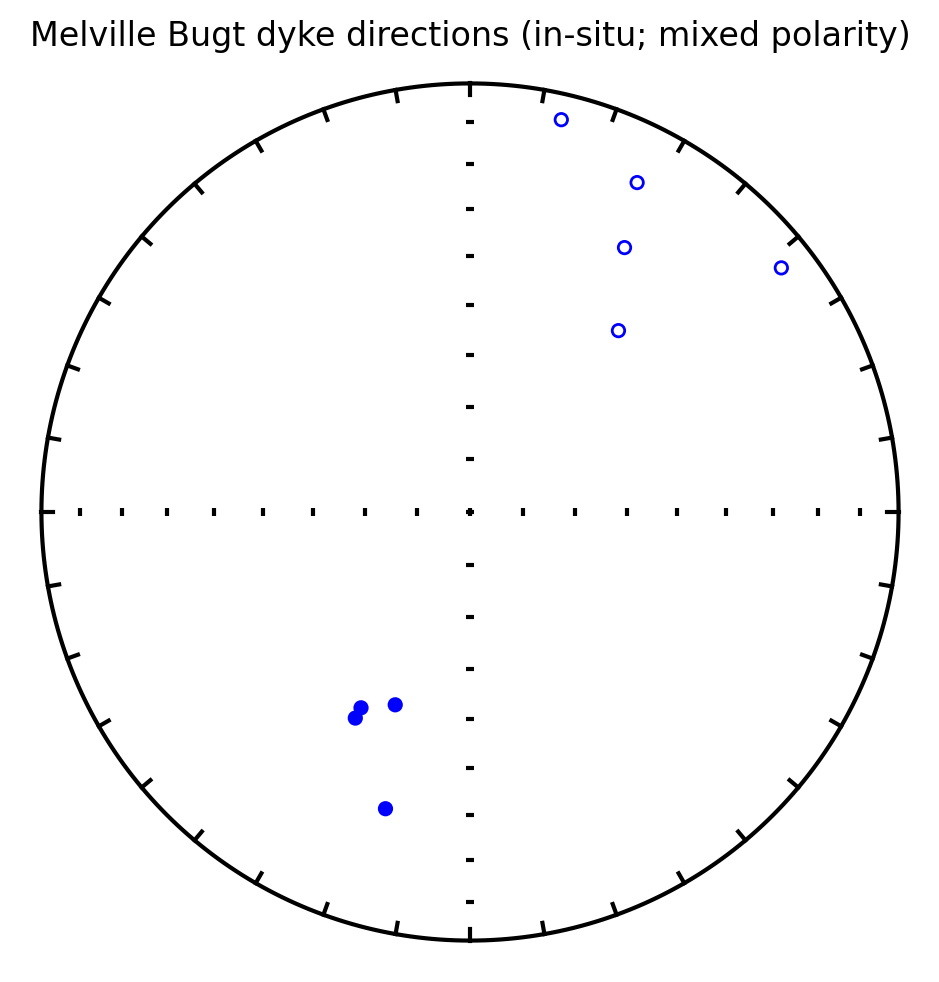

Plon: 274.5  Plat: 4.0
Number of directions in mean (n): 9
Angular radius of 95% confidence (A_95): 9.3
Precision parameter (k) estimate: 31.3

prior compilation (GPMDB 9495): 5 N / 273.8 E, A95 8.7, N=9 (reported at the +5 pole;
Halls et al. 2011 report the -5 S antipode)


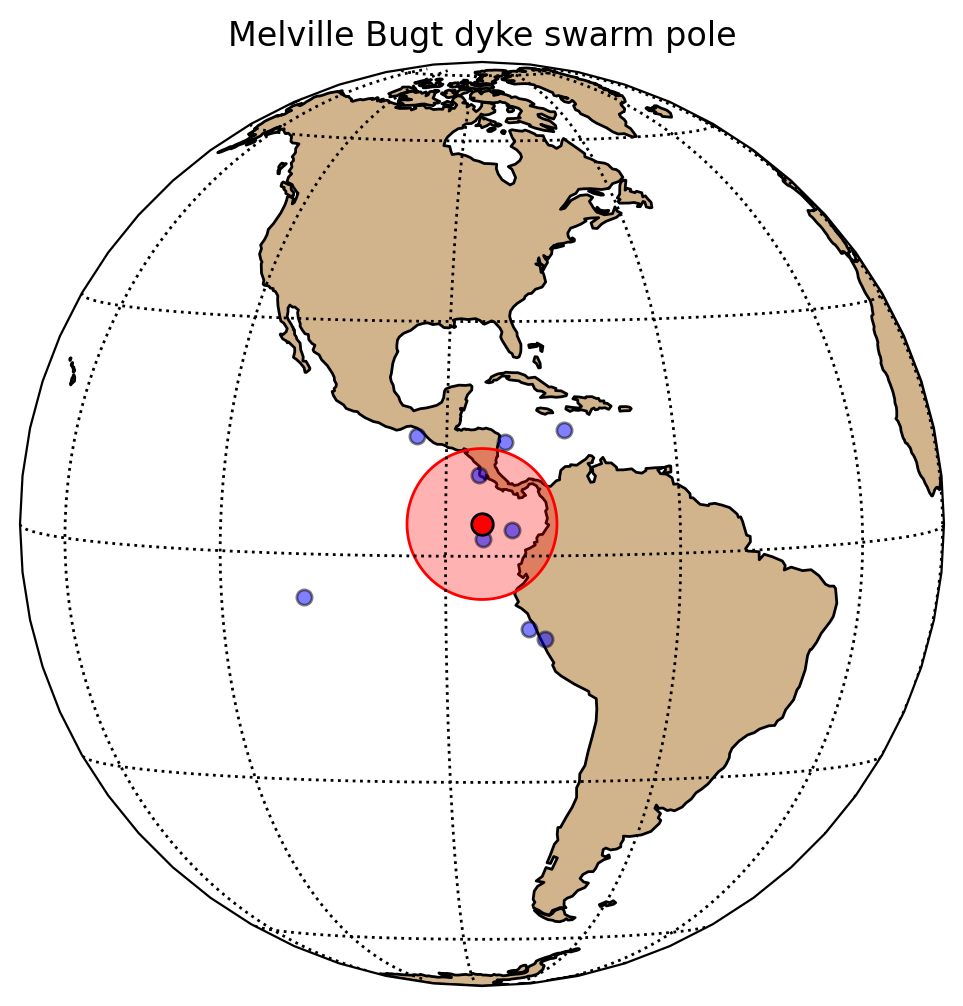

In [3]:
ipmag.plot_net()
ipmag.plot_di(primary['dir_dec'].tolist(), primary['dir_inc'].tolist(),
              color='blue', marker='o')
plt.title('Melville Bugt dyke directions (in-situ; mixed polarity)')
plt.show()

vgp_block, pole_mean = pt.compute_mean_pole(primary, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nprior compilation (GPMDB 9495): 5 N / 273.8 E, A95 8.7, N=9 (reported at the +5 pole;')
print('Halls et al. 2011 report the -5 S antipode)')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Melville Bugt dyke swarm pole')
plt.show()

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(primary, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)

Dec: 208.5  Inc: 31.0
Number of directions in mean (n): 9
Angular radius of 95% confidence (a_95): 13.1
Precision parameter (k) estimate: 16.5


## Paleosecular variation and VGP-shape diagnostics

A_95 of 9.3 passes Deenen et al. (2011) criteria of being between 5.0 and 20.5 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

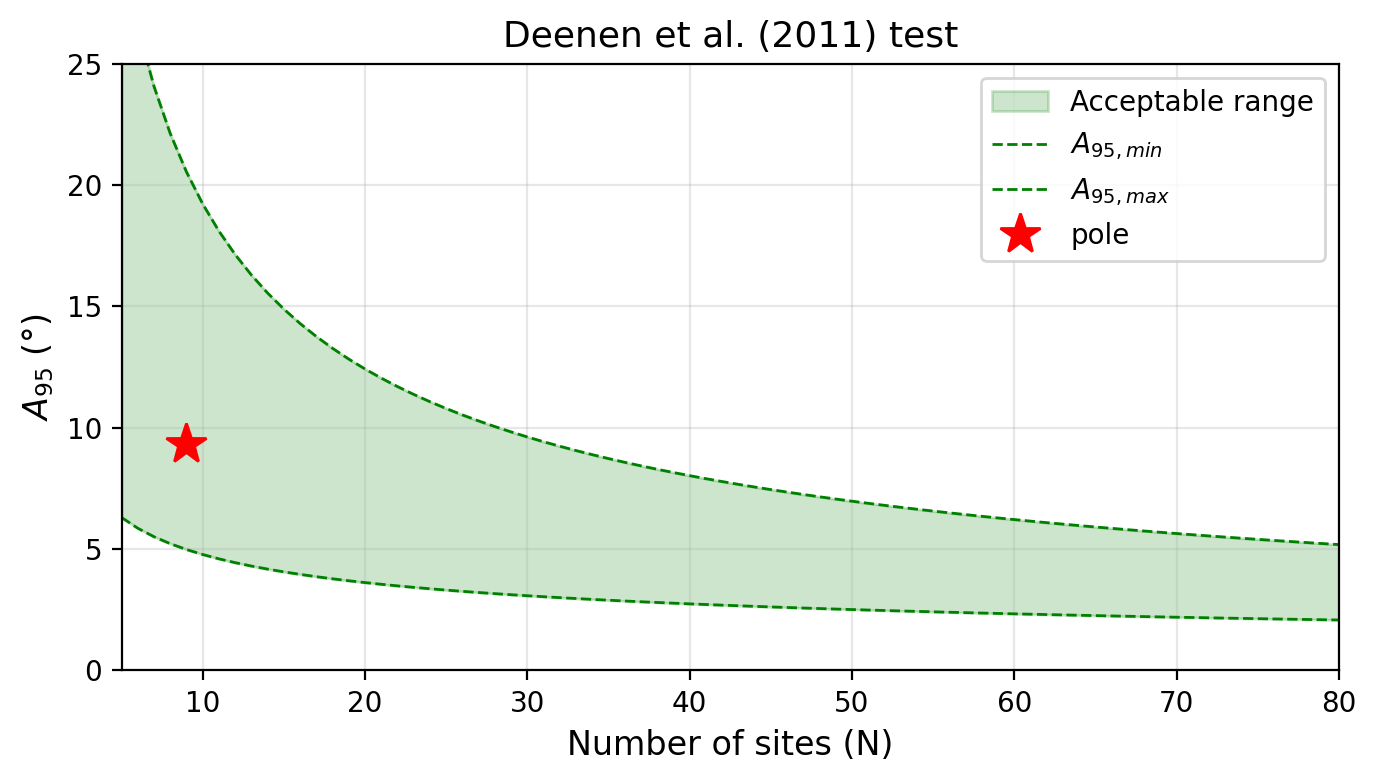

In [5]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

In [6]:
fishqq_result = pt.fishqq_vgps(primary, unify_polarity=True)
fishqq_result

you need N> 10 for at least one mode


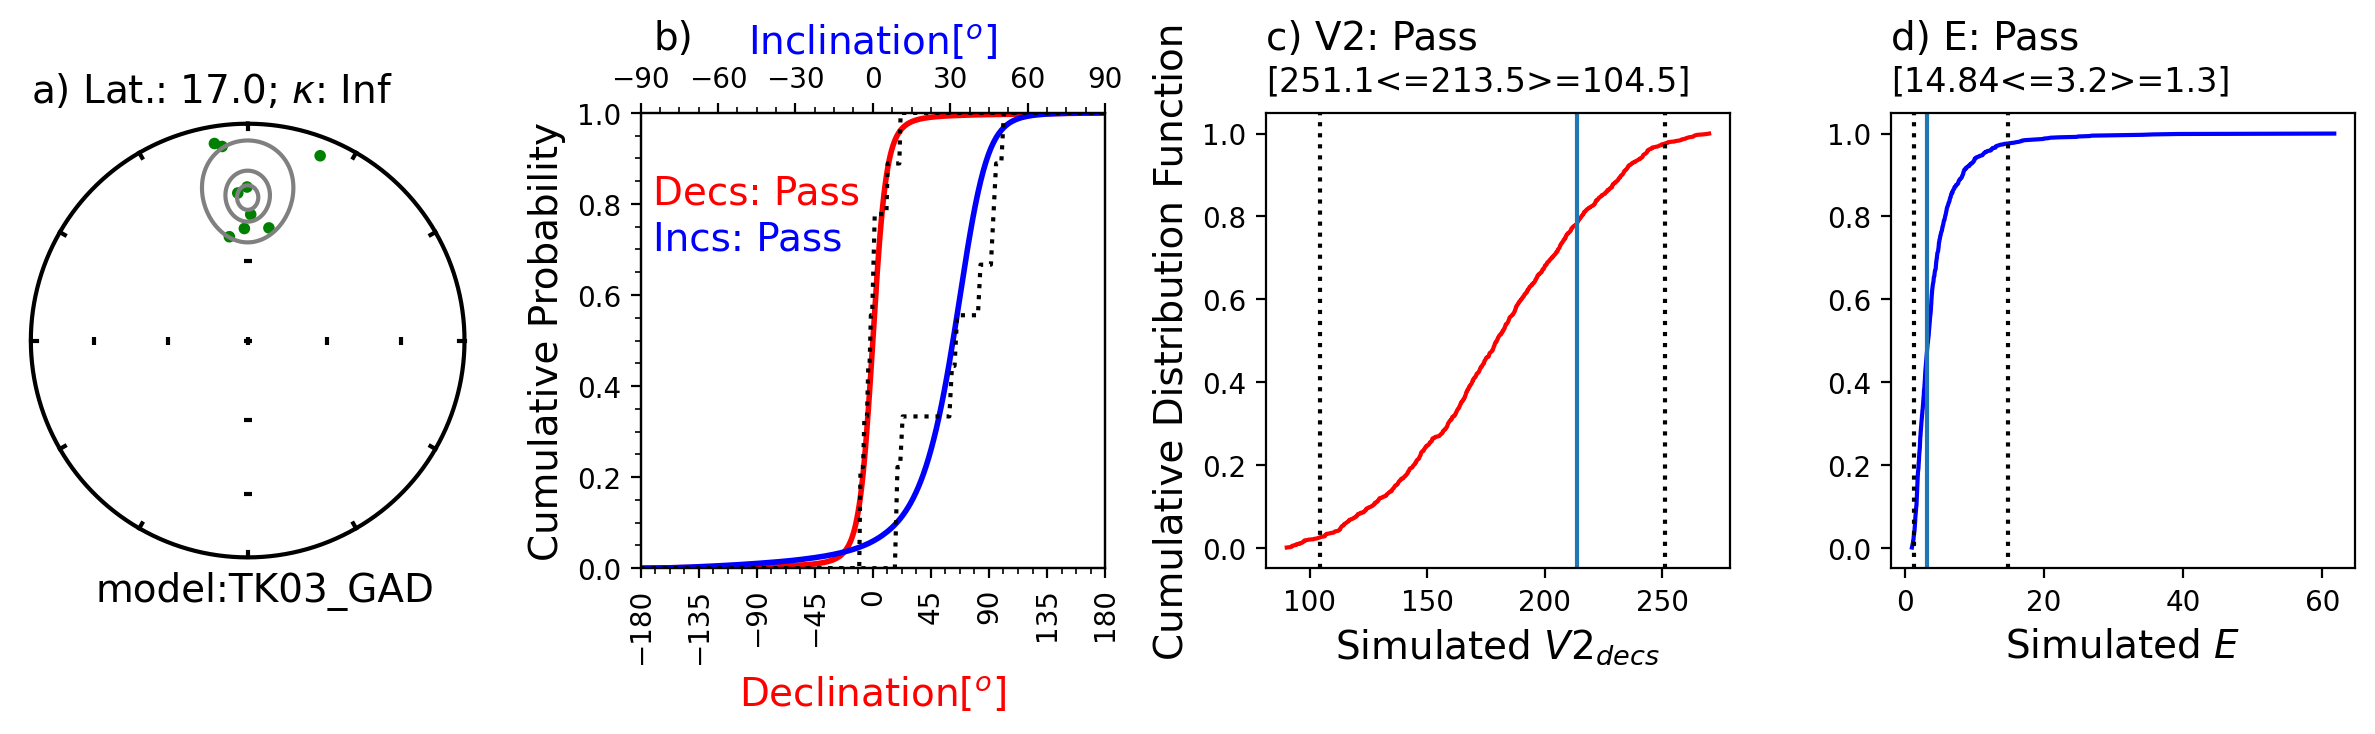

paleolatitude = 17.0 deg; elongation E = 3.20 (consistent with TK03.GAD)


In [7]:
try:
    svei_result = pt.svei_test_vgps(primary, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(primary, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Melville Bugt pole in the context of the Laurentia APWP

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


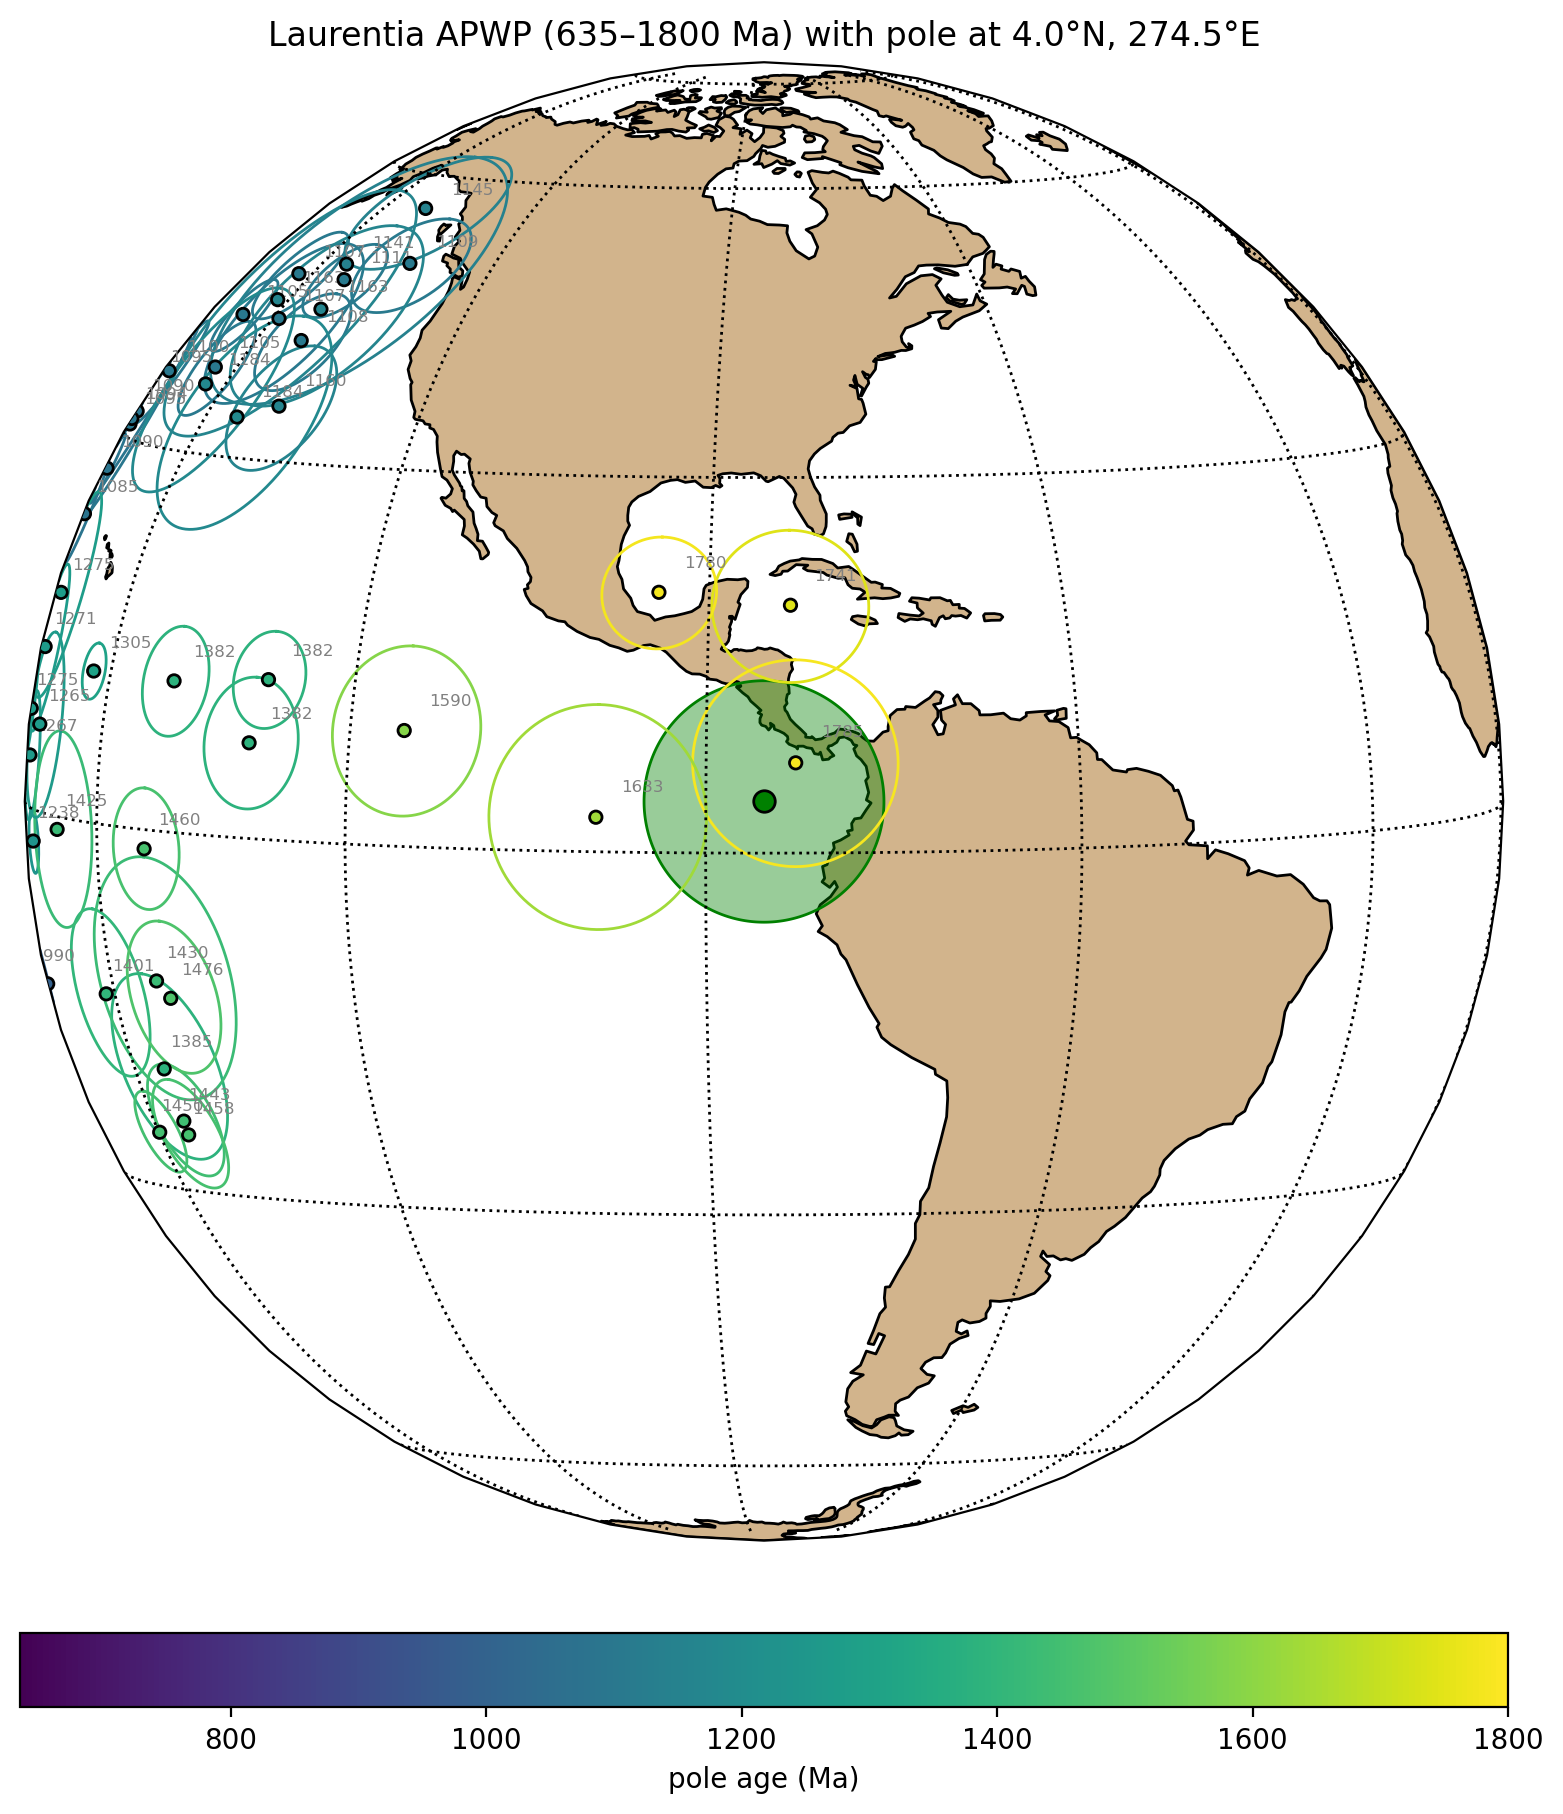

In [8]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

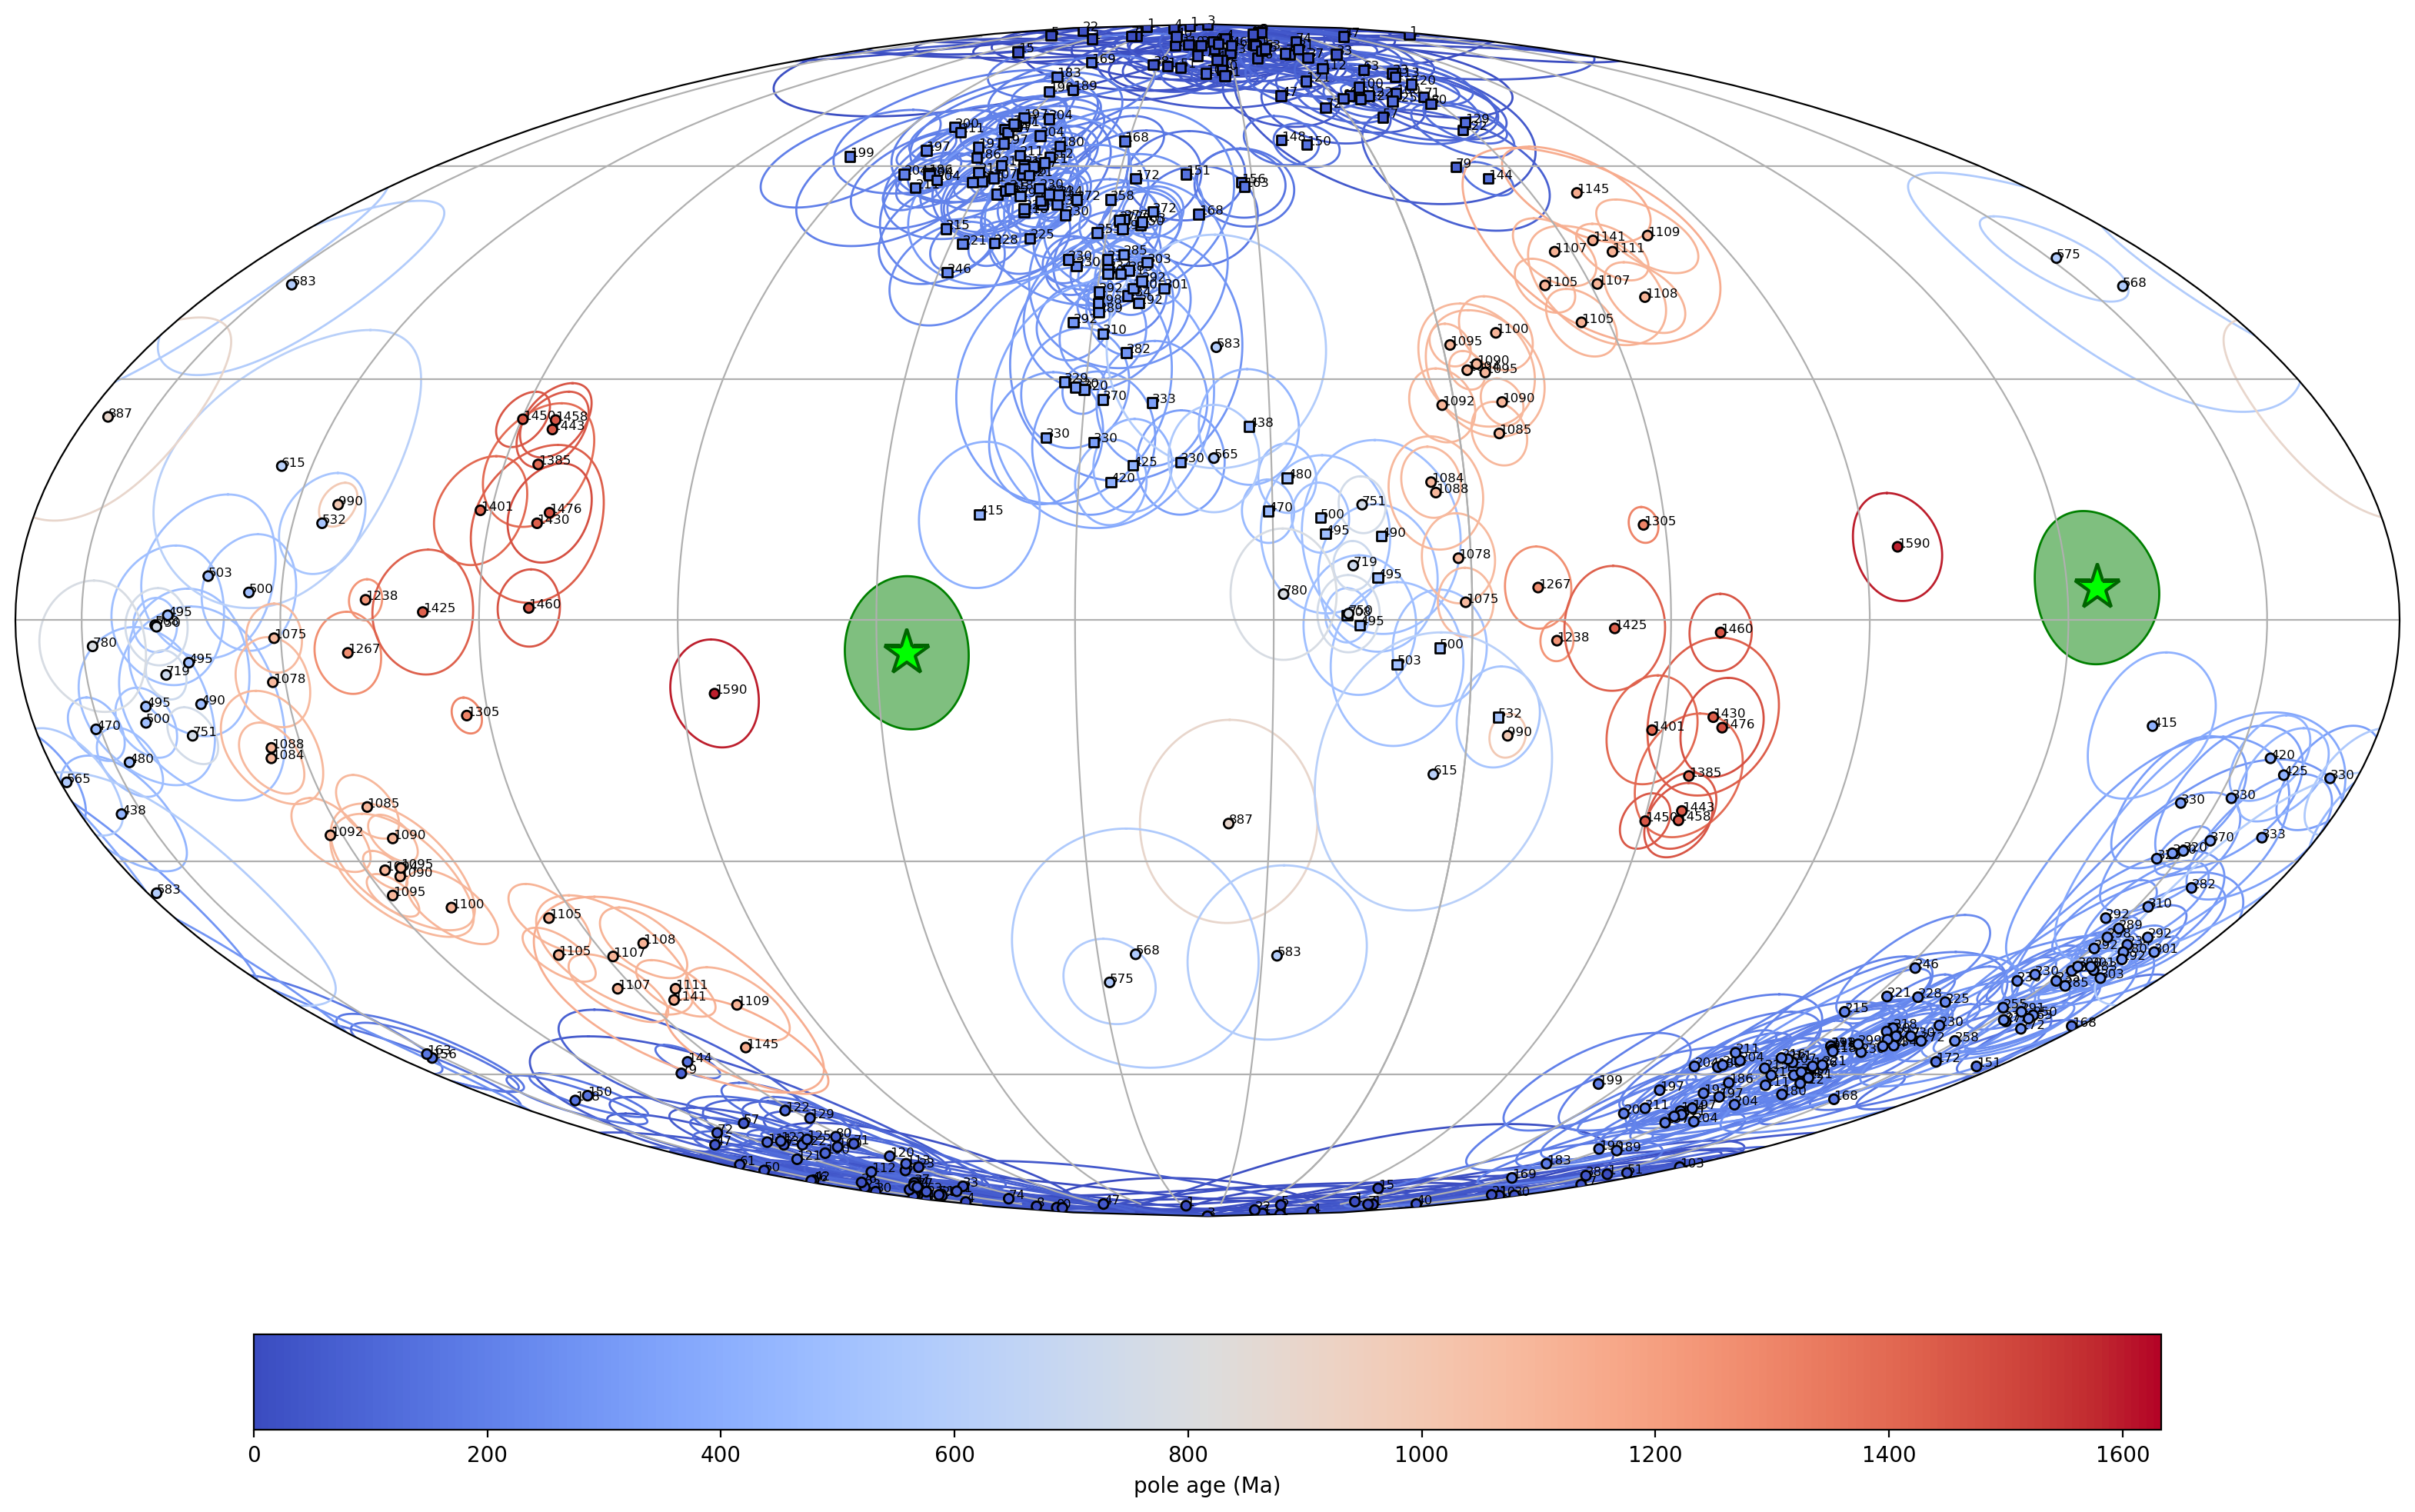

<GeoAxesSubplot:>

In [9]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Melville Bugt diabase dykes', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1633)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb baddeleyite 1633 Ma (1635 ± 2.7, 1632 ± 1.1, 1629.4 ± 0.8 Ma; Halls et al., 2011). |
| 2 | Techniques and statistical analysis | **1** | AF + thermal demagnetization with vector analysis; N = 9 dyke means, K = 31.3, A95 = 9.3° passes the Deenen et al. (2011) envelope. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence (thermomagnetic analysis; Denyszyn, 2008). |
| 4 | Field tests constrain age of magnetization | **0** | No baked-contact or fold test (chilled-margin sampling was used for geochemical dyke fingerprinting, not as a country-rock baked-contact test). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous NW Greenland (Laurentia-Greenland) basement; vertical dykes need no tilt correction. |
| 6 | Presence of reversals | **1** | The swarm is of mixed polarity (normal and reversed dykes ~180° apart). |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **6/7** | Grade B |

## Nordic workshop summary

The Melville Bugt pole is recreated at the site level from the 9 primary-remanence
dykes of Halls et al. (2011). The recreation reproduces the prior compilation
pole (5°N/273.8°E, A95 8.7, GPMDB 9495) with an internally consistent k/A95 pair
(k 31.3, A95 9.3). Mixed polarity scores R6 = 1; the swarm is well dated by U-Pb
(R1 = 1). The pole is reported at the +5 position; Halls et al. give the −5
antipode.

In [10]:
melville_summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='Melville Bugt diabase dykes',
    sites=primary,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Primary characteristic remanent magnetization carried by magnetite; mixed polarity',
    tests='R+ (positive reversal test: normal and reversed dykes ~180 deg apart)',
    gpmdb_number='9495',
    percent_reversed=44,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='', R5=1, R6=1, R7=1, Grade='B',
    nominal_age=1633, lomagage=1628, himagage=1638,
    REF_method='U-Pb baddeleyite ages on the Melville Bugt dyke swarm: 1635 +/- 2.7, 1632 +/- 1.1, and 1629.4 +/- 0.8 Ma (Halls, Hamilton & Denyszyn, 2011).',
    POLE_AUTHORS='Halls, H. C., Hamilton, M. A., & Denyszyn, S. W.',
    YEAR=2011,
    JOURNAL='Dyke Swarms: Keys for Geodynamic Interpretation (Springer)',
    VOLUME='',
    VPAGES='509-535',
    TITLE='The Melville Bugt Dyke Swarm of Greenland: A Connection to the 1.5-1.6 Ga Fennoscandian Rapakivi Granite Province?',
    COMMENT='Melville Bugt pole recreated at the site level from the 9 primary-remanence dykes of Halls et al. (2011) (audited contribution; QT dir_n_samples 8->9; OF chilled margin not counted as a separate dyke). Recreated 4.0N/274.5E with an internally consistent k=31.3/A95=9.3 (the source mixed the paper A95 8.7 with a recomputed k); reproduces the prior compilation pole (5N/273.8E, GPMDB 9495). Mixed polarity -> R6=1; U-Pb ca. 1633 Ma -> R1=1. Reported at +5; Halls et al. give the -5 antipode. No field test (R4=0). Grade B.'
)
pt.save_nordic_summary(melville_summary, '1633_Melville_Bugt')
melville_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,Melville Bugt diabase dykes,GPMDB:9495,Primary characteristic remanent magnetization ...,R+ (positive reversal test: normal and reverse...,0,74.4,301.6,9,57,...,1638,U-Pb baddeleyite ages on the Melville Bugt dyk...,Melville Bugt diabase dykes,"Halls, H. C., Hamilton, M. A., & Denyszyn, S. W.",2011,Dyke Swarms: Keys for Geodynamic Interpretatio...,,509-535,The Melville Bugt Dyke Swarm of Greenland: A C...,Melville Bugt pole recreated at the site level...
